In [3]:
import pandas as pd
import numpy as np  

In [6]:
df = pd.read_csv(
    "../data/spam",
    sep="\t",
    header=None,
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(403)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.shape

(5169, 2)

In [11]:
df["label"].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

In [12]:
df["label"].value_counts(normalize=True) * 100

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

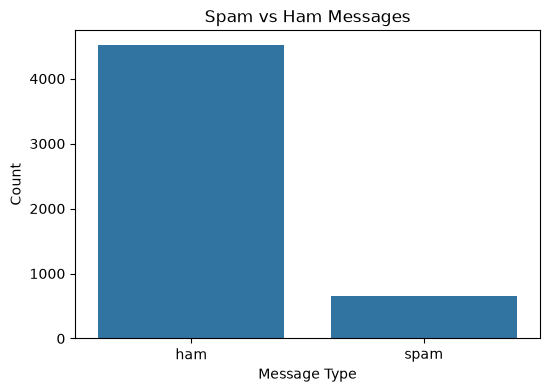

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df)

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

In [15]:
df["message_length"] = df["message"].apply(len)

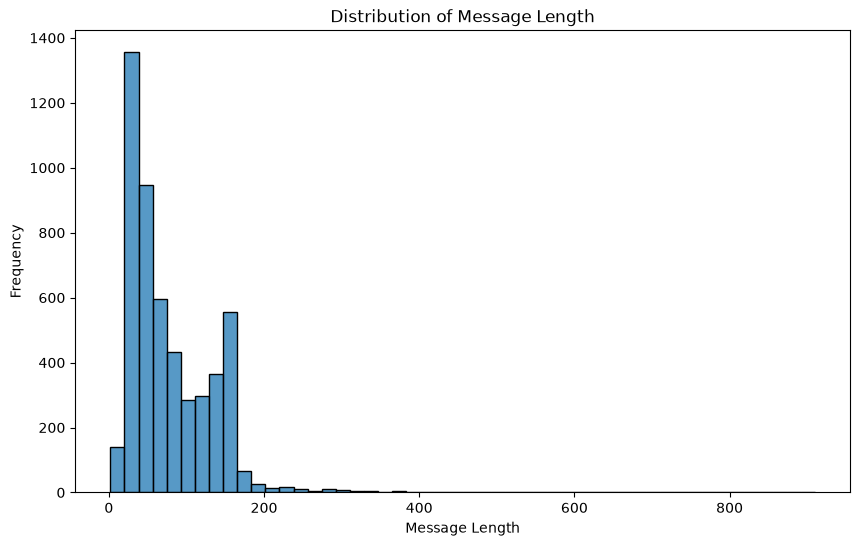

In [16]:
plt.figure(figsize=(10,6))

sns.histplot(df["message_length"], bins=50)

plt.title("Distribution of Message Length")
plt.xlabel("Message Length")
plt.ylabel("Frequency")

plt.show()

In [17]:
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize

In [18]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [19]:
ps = PorterStemmer()

In [20]:
def transform_text(text):
    
    # 1. Convert to lowercase
    text = text.lower()
    
    # 2. Tokenize
    text = word_tokenize(text)
    
    # 3. Remove non-alphanumeric words
    y = []
    for word in text:
        if word.isalnum():
            y.append(word)
    
    # 4. Remove stopwords and punctuation
    text = y[:]
    y.clear()

    for word in text:
        if word not in stopwords.words("english") and word not in string.punctuation:
            y.append(word)

    # 5. Apply stemming
    text = y[:]
    y.clear()

    for word in text:
        y.append(ps.stem(word))

    # 6. Join words back into a sentence
    return " ".join(y)

In [21]:
df["transformed_message"] = df["message"].apply(transform_text)

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [23]:
tfidf = TfidfVectorizer(max_features=3000)

In [24]:
X = tfidf.fit_transform(df["transformed_message"]).toarray()

In [25]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(df["label"])

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()

mnb.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3622., 513.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.13,-2.09]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 3000)","[[ 0. , 0. , 0. ,..., 1.98,15.65, 0. ], [ 0.65, 0.37, 1. ,..., 0. , 0. , 1.14]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 3000)","[[-9.34,-9.34,-9.34,...,-8.25,-6.53,-9.34], [-7.95,-8.14,-7.76,...,-8.45,-8.45,-7.7 ]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3000


In [29]:
y_pred = mnb.predict(X_test)

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9748549323017408
Precision: 1.0
Recall   : 0.8142857142857143
F1 Score : 0.8976377952755905


In [31]:
confusion_matrix(y_test, y_pred)

array([[894,   0],
       [ 26, 114]])

In [32]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [33]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.960348162475822
Precision: 0.9626168224299065
Recall   : 0.7357142857142858
F1 Score : 0.8340080971659919


In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [35]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.9729206963249516
Precision: 0.9912280701754386
Recall   : 0.8071428571428572
F1 Score : 0.889763779527559


In [36]:
from sklearn.svm import SVC

svc = SVC(kernel="linear")

svc.fit(X_train, y_train)

y_pred_svc = svc.predict(X_test)

In [37]:
print("Accuracy :", accuracy_score(y_test, y_pred_svc))
print("Precision:", precision_score(y_test, y_pred_svc))
print("Recall   :", recall_score(y_test, y_pred_svc))
print("F1 Score :", f1_score(y_test, y_pred_svc))

Accuracy : 0.9787234042553191
Precision: 0.9758064516129032
Recall   : 0.8642857142857143
F1 Score : 0.9166666666666666


In [38]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svc)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_svc)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_svc)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_svc)
    ]
})

results.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
3,SVM,0.978723,0.975806,0.864286,0.916667
0,Naive Bayes,0.974855,1.000000,0.814286,0.897638
2,Random Forest,0.972921,0.991228,0.807143,0.889764
1,Logistic Regression,0.960348,0.962617,0.735714,0.834008


In [39]:
import joblib

joblib.dump(svc, "../models/model.pkl")
joblib.dump(tfidf, "../models/vectorizer.pkl")

['../models/vectorizer.pkl']

In [ ]:
msg = "Congratulations! You have won a FREE iPhone. Click here to claim."

vector = tfidf.transform([transform_text(msg)])

svc = joblib.load("../models/model.pkl")
print(encoder.inverse_transform(svc.predict(vector.toarray()))[0])

NotFittedError: This SVC instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.